In [1]:
from common import EnvOffline


In [2]:
from collections import defaultdict

import numpy as np
from scipy.spatial import distance_matrix


# クラスタリング
def greedy_cluster(points, group_sizes):
    N = len(points)
    M = len(group_sizes)
    assigned = np.full(N, -1)

    # 中心をランダムに選択
    centers_idx = np.random.choice(N, M, replace=False)
    centers = points[centers_idx]

    group_counts = [0] * M

    while -1 in assigned:
        for idx, p in enumerate(points):
            if assigned[idx] != -1:
                continue
            distances = np.linalg.norm(centers - p, axis=1)
            # 空きがあるグループから一番近いものを選択
            sorted_idx = np.argsort(distances)
            for gid in sorted_idx:
                if group_counts[gid] < group_sizes[gid]:
                    assigned[idx] = gid
                    group_counts[gid] += 1
                    break
        # 中心を再計算
        for gid in range(M):
            member_idx = np.where(assigned == gid)[0]
            centers[gid] = points[member_idx].mean(axis=0)

    return assigned


# Kruskal法のMST実装
class UnionFind:
    def __init__(self, n):
        self.par = list(range(n))

    def find(self, x):
        if self.par[x] == x:
            return x
        self.par[x] = self.find(self.par[x])
        return self.par[x]

    def unite(self, x, y):
        x = self.find(x)
        y = self.find(y)
        if x != y:
            self.par[y] = x
            return True
        return False


def kruskal_mst(group_points):
    n = len(group_points)
    edges = []
    dist_mat = distance_matrix(group_points, group_points)
    for i in range(n):
        for j in range(i + 1, n):
            edges.append((dist_mat[i, j], i, j))
    edges.sort()
    uf = UnionFind(n)
    total_length = 0
    for d, u, v in edges:
        if uf.unite(u, v):
            total_length += d
    return total_length


In [183]:
file_num = 1
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)


# 使用例
points = np.array(env.coordinates)
group_sizes = np.array(env.G)

assigned = greedy_cluster(points, group_sizes)

total_len = 0
all_group_points = []
for gid in range(len(group_sizes)):
    group_points = points[assigned == gid]
    all_group_points.append(group_points)
    total_len += kruskal_mst(group_points)

print(f"Total MST Length: {total_len}")

Total MST Length: 454653.9538277793


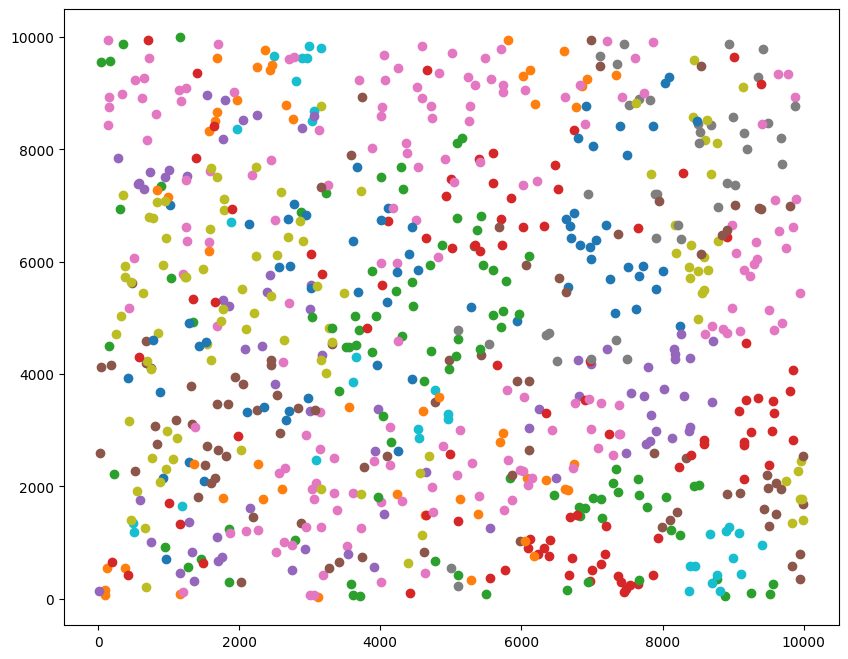

In [184]:
import matplotlib.pyplot as plt

# 点のプロット
plt.figure(figsize=(10, 8))
for gid, group_points in enumerate(all_group_points):
    plt.scatter(group_points[:, 0], group_points[:, 1], label=f"Group {gid + 1}")

[0, 1, 2, 6, 8, 10, 13, 14, 15, 11, 9, 19, 12, 18, 16, 5, 4, 17, 7, 3]
{19: 0, 0: 1, 11: 2, 8: 3, 10: 4, 4: 5, 13: 6, 16: 7, 18: 8, 7: 9, 9: 10, 5: 11, 6: 12, 1: 13, 14: 14, 15: 15, 3: 16, 2: 17, 17: 18, 12: 19}
制約 [(18, 4), (9, 16), (18, 17), (6, 9), (10, 4), (6, 17), (15, 18), (19, 5), (14, 19), (7, 3), (14, 12), (2, 5), (10, 18), (4, 7), (0, 11)]
初期ランキング [19, 0, 11, 8, 10, 4, 13, 16, 18, 7, 9, 5, 6, 1, 14, 15, 3, 2, 17, 12]
最終順位: [19, 0, 11, 8, 10, 4, 13, 16, 18, 7, 9, 5, 6, 1, 14, 15, 3, 2, 17, 12]


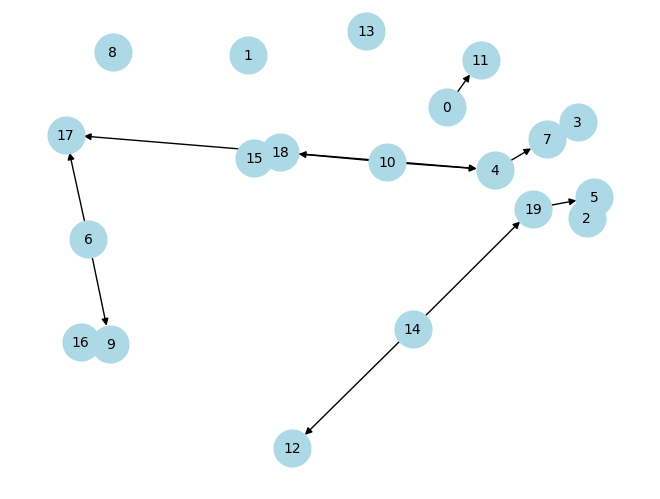

In [185]:
import random
from typing import List, Tuple

import networkx as nx
import numpy as np

# 棒の数
N = 20

# 制約の数
M = 15

# 初期推定ランキング（ランダムに生成する例）
initial_ranking = np.random.permutation(N).tolist()


# 制約情報(Li < Lj)をランダムに生成する例
def generate_constraints(num_sticks: int, num_constraints: int) -> List[Tuple[int, int]]:
    constraints = set()
    while len(constraints) < num_constraints:
        i, j = random.sample(range(num_sticks), 2)
        constraints.add((i, j))  # Li < Lj
    return list(constraints)


constraints = generate_constraints(N, M)


# グラフを作成する
def create_graph(constraints: List[Tuple[int, int]]) -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_nodes_from(range(N))
    G.add_edges_from(constraints)
    return G


graph = create_graph(constraints)


# ランキングを生成する（トポロジカルソートを使用）
def generate_ranking(graph: nx.DiGraph, initial_ranking: List[int]) -> List[int]:
    if not nx.is_directed_acyclic_graph(graph):
        raise ValueError("制約に矛盾があります。サイクルが存在します。")

    # グラフ描画
    pos = nx.spring_layout(graph)
    nx.draw(graph, pos, with_labels=True, node_color="lightblue", node_size=700, font_size=10)

    # トポロジカルソートを行う
    topo_sorted = list(nx.topological_sort(graph))

    # 初期ランキングの位置を保持（順位復元用）
    initial_rank_positions = {stick: rank for rank, stick in enumerate(initial_ranking)}
    print(topo_sorted)
    print(initial_rank_positions)

    # トポロジカル順序で同順位の要素を初期値に近い順に並び替えるための安定ソート
    topo_sorted.sort(key=lambda x: initial_rank_positions[x])

    return topo_sorted


# ランキングを生成
final_ranking = generate_ranking(graph, initial_ranking)

# 結果の確認
print("制約", constraints)
print("初期ランキング", initial_ranking)
print("最終順位:", final_ranking)

In [186]:
import heapq
import random
from collections import defaultdict
from typing import List, Tuple

import numpy as np

# 棒の数と制約数
N = 20
M = 15

# 初期ランキングをランダムに生成（0が最も高順位）
initial_ranking = np.random.permutation(N).tolist()


# 制約生成
def generate_constraints(num_sticks: int, num_constraints: int) -> List[Tuple[int, int]]:
    constraints = set()
    while len(constraints) < num_constraints:
        i, j = random.sample(range(num_sticks), 2)
        constraints.add((i, j))  # Li < Lj
    return list(constraints)


constraints = generate_constraints(N, M)


# 優先度付きトポロジカルソート
def priority_topological_sort(N: int, constraints: List[Tuple[int, int]], initial_ranking: List[int]) -> List[int]:
    graph = defaultdict(list)
    in_degree = [0] * N

    # グラフと入次数を作成
    for u, v in constraints:
        graph[u].append(v)
        in_degree[v] += 1

    # 初期ランキングの優先度を取得
    initial_priority = {node: rank for rank, node in enumerate(initial_ranking)}

    # 入次数0のノードを優先度キューに追加（優先度は初期ランキングに基づく）
    heap = []
    for node in range(N):
        if in_degree[node] == 0:
            heapq.heappush(heap, (initial_priority[node], node))

    result = []

    while heap:
        _, u = heapq.heappop(heap)
        result.append(u)

        for v in graph[u]:
            in_degree[v] -= 1
            if in_degree[v] == 0:
                heapq.heappush(heap, (initial_priority[v], v))

    if len(result) != N:
        raise ValueError("制約にサイクルがあります。ランキングを生成できませんでした。")

    return result


# ランキング生成
final_ranking = priority_topological_sort(N, constraints, initial_ranking)


# 結果の確認
print("制約", constraints)
print("初期ランキング", initial_ranking)
print("最終順位:", final_ranking)

制約 [(12, 4), (0, 7), (15, 11), (18, 17), (10, 5), (13, 7), (9, 6), (7, 9), (6, 10), (13, 6), (15, 2), (15, 3), (8, 2), (1, 19), (19, 5)]
初期ランキング [2, 7, 17, 14, 3, 4, 5, 9, 11, 12, 10, 13, 1, 15, 18, 19, 8, 6, 0, 16]
最終順位: [14, 12, 4, 13, 1, 15, 3, 11, 18, 17, 19, 8, 2, 0, 7, 9, 6, 10, 5, 16]


In [ ]:
def scc(
    graph: dict[int, list[int]],  # 隣接リスト
    r_graph: dict[int, list[int]],  # 逆グラフ
    vs: list[int],  # 頂点のリスト
):
    order = []
    used = {v: 0 for v in vs}
    group = {v: None for v in vs}

    def dfs(s):
        used[s] = 1
        for t in graph[s]:
            if not used[t]:
                dfs(t)
        order.append(s)

    def rdfs(s, col):
        group[s] = col
        used[s] = 1
        for t in r_graph[s]:
            if not used[t]:
                rdfs(t, col)

    for i in vs:
        if not used[i]:
            dfs(i)

    used = {v: 0 for v in vs}
    label_num = 0
    for s in reversed(order):
        if not used[s]:
            rdfs(s, label_num)
            label_num += 1
    return label_num, group


# 縮約後のグラフを構築
def construct(
    graph: dict[int, list[int]],  # 隣接リスト
    label_num: int,
    group: dict[int, int],  # 頂点が属するグループ
    vs: list[int],  # 頂点のリスト
):
    ssc_graph: list[set] = [set() for _ in range(label_num)]
    belong_lists: list[list[int]] = [[] for _ in range(label_num)]
    for v in vs:
        lbs = group[v]
        for w in graph[v]:
            lbt = group[w]
            if lbs == lbt:
                continue
            ssc_graph[lbs].add(lbt)
        belong_lists[lbs].append(v)
    return ssc_graph, belong_lists


def construct_dag_from_edges(
    edges: list[tuple[int, int]],  # 辺のリスト
    vs: list[int],  # 頂点のリスト
):
    """隣接リストを構築する"""
    graph: dict[int, list[int]] = {v: [] for v in vs}
    graph_r: dict[int, list[int]] = {v: [] for v in vs}
    for e in edges:
        v1, v2 = e
        graph[v1].append((v2))
        graph_r[v2].append((v1))
    return graph, graph_r

In [40]:
constraints = [
    (0, 1),  # L0 <= L1
    (1, 2),  # L1 <= L2
    (2, 0),  # L2 <= L0 → L0 == L1 == L2
    (3, 4),  # L3 <= L4
    (4, 5),  # L4 <= L5
]

for _ in range(2000):
    v1 = random.randint(50, 320)
    v2 = random.randint(50, 320)
    if v1 == v2:
        continue
    constraints.append((v1, v2))

vs = set()
for u, v in constraints:
    vs.add(u)
    vs.add(v)
vs = list(vs)

In [41]:
# ランキングを縮約後の数値に変換
# 優先順位つきトポロジカルソートする
# 縮約したグループを見ていって、1以上のグループがあれば、ソート内に埋め込む

In [42]:
graph, graph_r = construct_dag_from_edges(constraints, vs)
label_num, group = scc(graph, graph_r, vs)
label_num, group
ssc_graph, belong_lists = construct(graph, label_num, group, vs)

In [ ]:
label_num

ValueError: not enough values to unpack (expected 2, got 0)

In [8]:
import networkx as nx

In [ ]:
import random
import time


def nx_scc(vs, constraints):
    # 1. 有向グラフを構築
    nx_graph = nx.DiGraph()
    nx_graph.add_nodes_from(vs)
    nx_graph.add_edges_from(constraints)

    # 2. 強連結成分（SCC）を求める
    # scc_list = list(nx.strongly_connected_components(nx_graph))
    ret = nx.strongly_connected_components(nx_graph)
    print(ret)
    # print("SCC:", scc_list)
    # → 例えば [{0,1,2}, {3}, {4}, {5}]

    # # 3. SCCグループにIDを割り振る
    # node_to_scc = {}
    # for idx, _scc in enumerate(scc_list):
    #     for node in _scc:
    #         node_to_scc[node] = idx

    # # 4. SCC間で縮約グラフ（DAG）を構築
    # dag = nx.DiGraph()
    # dag.add_nodes_from(range(len(scc_list)))

    # for u, v in constraints:
    #     su = node_to_scc[u]
    #     sv = node_to_scc[v]
    #     if su != sv:
    #         dag.add_edge(su, sv)

    # # 5. DAGに対してトポロジカルソートを実行
    # sorted_scc_ids = list(nx.topological_sort(dag))
    # print("トポロジカル順（SCC単位）:", sorted_scc_ids)

    # # 6. 元のノード順序に復元
    # final_order = []
    # for scc_id in sorted_scc_ids:
    #     group = list(scc_list[scc_id])
    #     group.sort()  # 推定順などで並べても良い
    #     final_order.extend(group)

    # print("最終ランキング:", final_order)


In [15]:
st = time.perf_counter()
nx_scc(vs, constraints)
et = time.perf_counter() - st
print(et)

<generator object strongly_connected_components at 0x7f1e5b4374c0>
0.4366336720995605


0.5507024480029941
